# Wind Turbine Gearbox Failure Prediction

This notebook implements a predictive maintenance system for wind turbine gearboxes using deep learning. We compare **supervised** (CNN) and **unsupervised** (Autoencoder) approaches across two feature sets:

- **Raw Sensors**: Original SCADA measurements
- **Rolling Features**: Statistical descriptors (mean, std, min, max) computed over sliding windows

## Methodology
1. **Temporal Train/Val/Test Split** with 14-day gaps to prevent data leakage
2. **Hyperparameter Optimization** using Optuna (10 trials per model)
3. **Multiple Runs** for statistical robustness
4. **Evaluation**: F1-Score, Precision-Recall curves, Confusion Matrices

In [86]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import optuna
import random
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (f1_score, confusion_matrix, classification_report, 
                             precision_recall_curve, average_precision_score)
from sklearn.utils.class_weight import compute_class_weight

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch: {torch.__version__} | Device: {device}")

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

PyTorch: 2.5.1 | Device: cuda


## 1. Setup & Configuration

In [87]:
event_info_df = pd.read_csv("Datasets/Wind Farm A/event_info.csv", sep=";")

## 2. Data Loading

We use SCADA data from **Wind Farm A** containing sensor measurements from 3 turbines. The `event_info.csv` file contains maintenance records used to create failure labels.

In [88]:
file_paths = [
    "Datasets/Wind Farm A/datasets/72.csv",
    "Datasets/Wind Farm A/datasets/10.csv",
    "Datasets/Wind Farm A/datasets/51.csv"
]
dfs = [pd.read_csv(path, sep=";") for path in file_paths]
df = pd.concat(dfs, ignore_index=True)

In [89]:
feature_description_df = pd.read_csv("Datasets/Wind Farm A/feature_description.csv", sep=";")

In [90]:
DRIVETRAIN_FEATURES = [
    'time_stamp', 'asset_id', 
    'sensor_0_avg', 'wind_speed_3_avg', 'power_30_avg', 'sensor_52_avg',
    'sensor_11_avg', 'sensor_12_avg', 'sensor_13_avg', 'sensor_14_avg',
    'sensor_52_std', 'sensor_18_std'
]
df_drivetrain = df[DRIVETRAIN_FEATURES].copy()

## 3. Feature Selection & Labeling

**Selected Features** (drivetrain-related sensors):
- Temperature sensors (`sensor_11` to `sensor_14`)
- Vibration/load indicators (`sensor_0`, `sensor_52`, `sensor_18`)
- Operational context (`wind_speed`, `power`)

**Labeling Strategy**: Samples within **14 days before** a gearbox/bearing/drive failure event are labeled as `1` (pre-failure), otherwise `0` (normal).

In [91]:
df_drivetrain['time_stamp'] = pd.to_datetime(df_drivetrain['time_stamp'])
event_info_df['event_start'] = pd.to_datetime(event_info_df['event_start'])
event_info_df['event_end'] = pd.to_datetime(event_info_df['event_end'])

df_drivetrain['label'] = 0
TARGET_KEYWORDS = ['Gearbox', 'Bearing', 'Drive']
WARNING_DAYS = 14

for _, event in event_info_df.iterrows():
    description = str(event['event_description'])
    is_target = any(kw.lower() in description.lower() for kw in TARGET_KEYWORDS)
    
    if is_target and (event['asset'] in df_drivetrain['asset_id'].unique()):
        start_warning = event['event_start'] - pd.Timedelta(days=WARNING_DAYS)
        mask = ((df_drivetrain['asset_id'] == event['asset']) & 
                (df_drivetrain['time_stamp'] >= start_warning) & 
                (df_drivetrain['time_stamp'] <= event['event_end']))
        df_drivetrain.loc[mask, 'label'] = 1

print(f"Label distribution:\n{df_drivetrain['label'].value_counts()}")

Label distribution:
label
0    145212
1     16898
Name: count, dtype: int64


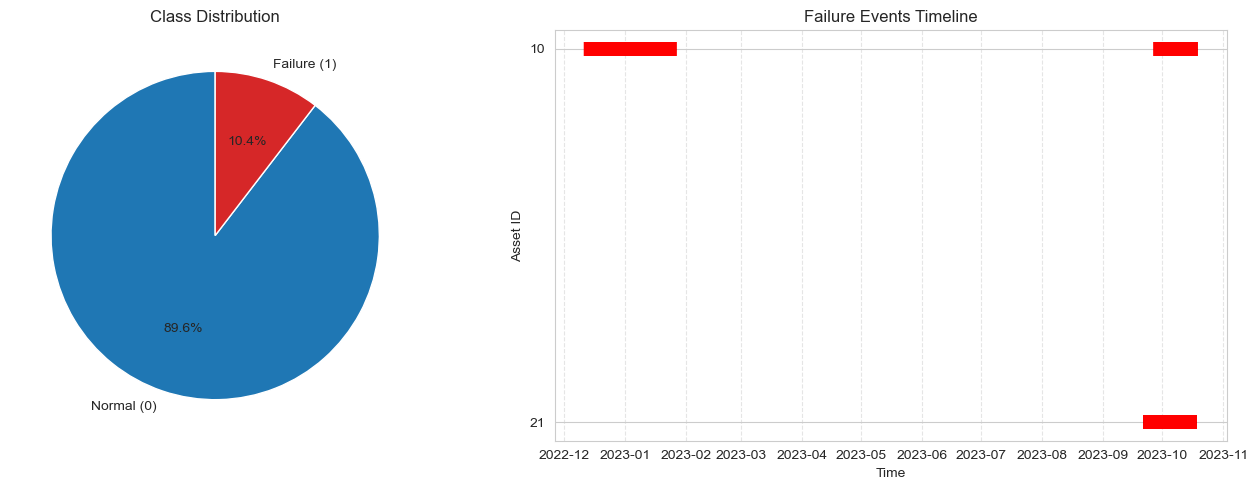

In [92]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

label_counts = df_drivetrain['label'].value_counts()
axes[0].pie(label_counts, labels=['Normal (0)', 'Failure (1)'], autopct='%1.1f%%', 
            colors=['#1f77b4', '#d62728'], startangle=90)
axes[0].set_title("Class Distribution")

failure_data = df_drivetrain[df_drivetrain['label'] == 1]
axes[1].scatter(failure_data['time_stamp'], failure_data['asset_id'].astype(str), 
                c='red', marker='|', s=100)
axes[1].set_title("Failure Events Timeline")
axes[1].set_xlabel("Time")
axes[1].set_ylabel("Asset ID")
axes[1].grid(True, axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [93]:
GAP_DAYS = 14
WINDOW_SIZE = 144
TIME_STEPS = 144
BATCH_SIZE = 32

df_drivetrain = df_drivetrain.sort_values(['asset_id', 'time_stamp']).reset_index(drop=True)

train_split = df_drivetrain['time_stamp'].quantile(0.60)
val_split = df_drivetrain['time_stamp'].quantile(0.80)

train_gap_end = train_split + pd.Timedelta(days=GAP_DAYS)
val_gap_start = val_split - pd.Timedelta(days=GAP_DAYS)
val_gap_end = val_split + pd.Timedelta(days=GAP_DAYS)

train_raw = df_drivetrain[df_drivetrain['time_stamp'] < train_split].copy()
val_raw = df_drivetrain[(df_drivetrain['time_stamp'] > train_gap_end) & 
                        (df_drivetrain['time_stamp'] < val_gap_start)].copy()
test_raw = df_drivetrain[df_drivetrain['time_stamp'] > val_gap_end].copy()

print(f"Train: {len(train_raw):,} | Val: {len(val_raw):,} | Test: {len(test_raw):,}")

Train: 97,264 | Val: 20,325 | Test: 26,387


In [94]:
# Diagnostic: Check label distribution across splits
print("=" * 60)
print("LABEL DISTRIBUTION ACROSS SPLITS")
print("=" * 60)

for name, df in [("Train", train_raw), ("Val", val_raw), ("Test", test_raw)]:
    total = len(df)
    failures = df['label'].sum()
    normal = total - failures
    print(f"{name:6s}: {total:>7,} samples | Normal: {normal:>6,} ({100*normal/total:.1f}%) | Failure: {failures:>6,} ({100*failures/total:.1f}%)")

print("=" * 60)
print(f"Total failures in dataset: {df_drivetrain['label'].sum():,} / {len(df_drivetrain):,} ({100*df_drivetrain['label'].mean():.1f}%)")
print("=" * 60)

LABEL DISTRIBUTION ACROSS SPLITS
Train :  97,264 samples | Normal: 90,741 (93.3%) | Failure:  6,523 (6.7%)
Val   :  20,325 samples | Normal: 20,325 (100.0%) | Failure:      0 (0.0%)
Test  :  26,387 samples | Normal: 16,012 (60.7%) | Failure: 10,375 (39.3%)
Total failures in dataset: 16,898 / 162,110 (10.4%)


## 4. Temporal Train/Validation/Test Split

We use a **time-based split** (60/20/20) with **14-day gaps** between sets to:
- Prevent temporal data leakage
- Simulate realistic deployment conditions
- Ensure the model generalizes to future data

In [95]:
def compute_rolling_features(df, window_size):
    sensor_cols = [c for c in df.columns if c not in ['time_stamp', 'asset_id', 'label']]
    
    df_diff = df.groupby('asset_id')[sensor_cols].diff().fillna(0)
    df_diff.columns = [f"{c}_diff" for c in df_diff.columns]
    df = pd.concat([df, df_diff], axis=1)
    
    roll_cols = [c for c in df.columns if c not in ['time_stamp', 'asset_id', 'label']]
    rolling = df.groupby('asset_id')[roll_cols].rolling(window=window_size).agg(['mean', 'std', 'min', 'max'])
    rolling.columns = [f"{c}_{s}" for c, s in rolling.columns]
    rolling = rolling.reset_index(level=0, drop=True)
    
    df_out = df[['time_stamp', 'asset_id']].join(rolling)
    df_out['label'] = df['label']
    return df_out.dropna()

def prepare_simple_dataset(df):
    sensor_cols = [c for c in df.columns if c not in ['time_stamp', 'asset_id', 'label']]
    return df[['time_stamp', 'asset_id'] + sensor_cols + ['label']].dropna()

train_df = compute_rolling_features(train_raw, WINDOW_SIZE)
val_df = compute_rolling_features(val_raw, WINDOW_SIZE)
test_df = compute_rolling_features(test_raw, WINDOW_SIZE)

train_df_simple = prepare_simple_dataset(train_raw)
val_df_simple = prepare_simple_dataset(val_raw)
test_df_simple = prepare_simple_dataset(test_raw)

print(f"WITH Descriptors  - Train: {train_df.shape} | Val: {val_df.shape} | Test: {test_df.shape}")
print(f"WITHOUT Descriptors - Train: {train_df_simple.shape} | Val: {val_df_simple.shape} | Test: {test_df_simple.shape}")

WITH Descriptors  - Train: (96833, 83) | Val: (20039, 83) | Test: (26101, 83)
WITHOUT Descriptors - Train: (97262, 13) | Val: (20325, 13) | Test: (26387, 13)


## 5. Feature Engineering

We create two datasets for comparison:

| Dataset | Description | Features |
|---------|-------------|----------|
| **Simple** | Raw sensor values | ~10 features |
| **Descriptors** | Rolling statistics (mean, std, min, max) + first differences | ~80 features |

The rolling window size matches the sequence length (144 time steps ≈ 1 day at 10-min intervals).

In [96]:
def create_sequences(X, y, time_steps, step=1):
    """
    Create sliding window sequences for time series data.
    
    Args:
        X: Feature array (n_samples, n_features)
        y: Label series
        time_steps: Window size
        step: Step size between windows
    
    Returns:
        Tuple of (sequences, labels) arrays
    """
    X_vals = X.astype(np.float32)
    y_vals = y.values.astype(np.float32)
    n_samples = (len(X) - time_steps) // step
    
    Xs = np.zeros((n_samples, time_steps, X.shape[1]), dtype=np.float32)
    ys = np.zeros(n_samples, dtype=np.float32)
    
    for i in range(n_samples):
        idx = i * step
        Xs[i] = X_vals[idx:idx + time_steps]
        ys[i] = y_vals[idx + time_steps]
    return Xs, ys


def prepare_data_loaders(train_df, val_df, test_df, time_steps, batch_size):
    """
    Prepare scaled sequences and DataLoaders for training.
    
    Args:
        train_df, val_df, test_df: DataFrames with features and labels
        time_steps: Sequence length
        batch_size: Batch size for DataLoaders
    
    Returns:
        dict with loaders, tensors, labels, and input dimension
    """
    feature_cols = [c for c in train_df.columns if c not in ['time_stamp', 'asset_id', 'label']]
    
    scaler = StandardScaler()
    X_train = scaler.fit_transform(train_df[feature_cols]).astype(np.float32)
    X_val = scaler.transform(val_df[feature_cols]).astype(np.float32)
    X_test = scaler.transform(test_df[feature_cols]).astype(np.float32)
    
    X_train_seq, y_train_seq = create_sequences(X_train, train_df['label'], time_steps)
    X_val_seq, y_val_seq = create_sequences(X_val, val_df['label'], time_steps)
    X_test_seq, y_test_seq = create_sequences(X_test, test_df['label'], time_steps)
    
    train_tensor = torch.tensor(X_train_seq)
    val_tensor = torch.tensor(X_val_seq)
    test_tensor = torch.tensor(X_test_seq)
    
    y_train_tensor = torch.tensor(y_train_seq).float()
    y_val_tensor = torch.tensor(y_val_seq).float()
    y_test_tensor = torch.tensor(y_test_seq).float()
    
    train_loader = DataLoader(TensorDataset(train_tensor, y_train_tensor), shuffle=True, batch_size=batch_size)
    val_loader = DataLoader(TensorDataset(val_tensor, y_val_tensor), shuffle=False, batch_size=batch_size)
    test_loader = DataLoader(TensorDataset(test_tensor, y_test_tensor), shuffle=False, batch_size=batch_size)
    
    return {
        'train_loader': train_loader, 'val_loader': val_loader, 'test_loader': test_loader,
        'train_tensor': train_tensor, 'val_tensor': val_tensor, 'test_tensor': test_tensor,
        'y_train': y_train_tensor, 'y_val': y_val_tensor, 'y_test': y_test_tensor,
        'y_train_seq': y_train_seq, 'y_val_seq': y_val_seq, 'y_test_seq': y_test_seq,
        'input_dim': X_train_seq.shape[2],
        'scaler': scaler
    }

data_desc = prepare_data_loaders(train_df, val_df, test_df, TIME_STEPS, BATCH_SIZE)
data_simple = prepare_data_loaders(train_df_simple, val_df_simple, test_df_simple, TIME_STEPS, BATCH_SIZE)

print(f"WITH Descriptors - Input dim: {data_desc['input_dim']}")
print(f"WITHOUT Descriptors - Input dim: {data_simple['input_dim']}")

WITH Descriptors - Input dim: 80
WITHOUT Descriptors - Input dim: 10


In [97]:
class LSTMAutoencoder(nn.Module):
    """LSTM-based Autoencoder for sequence anomaly detection."""
    
    def __init__(self, input_dim, hidden_dim, seq_len):
        super().__init__()
        self.seq_len = seq_len
        self.encoder = nn.LSTM(input_dim, hidden_dim, batch_first=True)
        self.decoder = nn.LSTM(hidden_dim, hidden_dim, batch_first=True)
        self.output = nn.Linear(hidden_dim, input_dim)

    def forward(self, x):
        _, (h, _) = self.encoder(x)
        h_rep = h.permute(1, 0, 2).repeat(1, self.seq_len, 1)
        decoded, _ = self.decoder(h_rep)
        return self.output(decoded)


class CNN1DAttention(nn.Module):
    """1D CNN with attention mechanism for sequence classification."""
    
    def __init__(self, input_dim, num_filters=16, kernel_size=3, dropout_rate=0.3):
        super().__init__()
        self.conv1 = nn.Conv1d(input_dim, num_filters, kernel_size, padding=kernel_size//2)
        self.bn1 = nn.BatchNorm1d(num_filters)
        self.conv2 = nn.Conv1d(num_filters, num_filters * 2, kernel_size, padding=kernel_size//2)
        self.bn2 = nn.BatchNorm1d(num_filters * 2)
        self.relu = nn.ReLU()
        self.att_score = nn.Linear(num_filters * 2, 1)
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.dropout = nn.Dropout(dropout_rate)
        self.classifier = nn.Linear(num_filters * 2, 1)

    def forward(self, x):
        x = x.permute(0, 2, 1)  # (B, features, seq)
        x = self.relu(self.bn1(self.conv1(x)))  # (B, filters, seq)
        x = self.relu(self.bn2(self.conv2(x)))  # (B, filters*2, seq)
        x_t = x.permute(0, 2, 1)  # (B, seq, filters*2)
        att_weights = torch.softmax(self.att_score(x_t), dim=1)  # (B, seq, 1)
        x_att = (x_t * att_weights).permute(0, 2, 1)  # (B, filters*2, seq)
        x = self.pool(x_att).squeeze(-1)  # (B, filters*2)
        return self.classifier(self.dropout(x))

## 6. Model Architectures

### LSTM Autoencoder (Unsupervised)
- **Encoder**: LSTM compresses sequence → latent vector
- **Decoder**: Reconstructs input sequence
- **Anomaly Detection**: High reconstruction error = potential failure

### CNN with Attention (Supervised)
- **1D Convolution**: Extracts local temporal patterns
- **Attention Mechanism**: Weights important time steps
- **Binary Classification**: Directly predicts failure probability

In [98]:
def train_autoencoder(model, train_loader, val_loader=None, epochs=10, lr=0.001, patience=3, verbose=True):
    """
    Train LSTM Autoencoder with optional early stopping.
    
    Args:
        model: LSTMAutoencoder instance
        train_loader: DataLoader for training data
        val_loader: DataLoader for validation (enables early stopping if provided)
        epochs: Maximum training epochs
        lr: Learning rate
        patience: Early stopping patience
        verbose: If True, print epoch progress
    
    Returns:
        dict with 'train_loss', 'val_loss', 'best_epoch'
    """
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)
    
    history = {'train_loss': [], 'val_loss': []}
    best_loss = float('inf')
    best_state = None
    epochs_no_improve = 0
    
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for inputs, targets in train_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            optimizer.zero_grad()
            loss = criterion(model(inputs), inputs)  # Autoencoder: reconstruct input
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            total_loss += loss.item() * inputs.size(0)
        
        train_loss = total_loss / len(train_loader.dataset)
        history['train_loss'].append(train_loss)
        
        val_loss = train_loss
        if val_loader:
            model.eval()
            val_total = 0
            with torch.no_grad():
                for inputs, targets in val_loader:
                    inputs, targets = inputs.to(device), targets.to(device)
                    val_total += criterion(model(inputs), targets).item() * inputs.size(0)
            val_loss = val_total / len(val_loader.dataset)
            history['val_loss'].append(val_loss)
        
        scheduler.step(val_loss)
        
        if val_loss < best_loss:
            best_loss = val_loss
            best_state = model.state_dict().copy()
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
        if verbose:
            print(f"Epoch {epoch+1}/{epochs} - Train: {train_loss:.6f}" + 
                  (f", Val: {val_loss:.6f}" if val_loader else "") +
                  (f" *" if epochs_no_improve == 0 else ""))
        
        if epochs_no_improve >= patience:
            if verbose:
                print(f"Early stopping at epoch {epoch+1}")
            break
    
    if best_state:
        model.load_state_dict(best_state)
    
    history['best_epoch'] = epoch + 1 - epochs_no_improve
    return history


def train_classifier(model, train_loader, val_loader=None, epochs=10, lr=0.001, pos_weight=None, patience=3, verbose=True):
    """
    Train CNN classifier with optional early stopping.
    
    Args:
        model: CNN1DAttention instance
        train_loader: DataLoader for training data
        val_loader: DataLoader for validation (enables early stopping if provided)
        epochs: Maximum training epochs
        lr: Learning rate
        pos_weight: Class weight for imbalanced data
        patience: Early stopping patience
        verbose: If True, print epoch progress
    
    Returns:
        dict with 'train_loss', 'train_acc', 'val_loss', 'val_acc', 'best_epoch'
    """
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)
    
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_loss = float('inf')
    best_state = None
    epochs_no_improve = 0
    
    for epoch in range(epochs):
        model.train()
        total_loss, correct, total = 0, 0, 0
        
        for inputs, targets in train_loader:
            inputs = inputs.to(device)
            targets = targets.to(device).unsqueeze(1)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            
            total_loss += loss.item() * inputs.size(0)
            correct += ((torch.sigmoid(outputs) > 0.5).float() == targets).sum().item()
            total += targets.size(0)
        
        train_loss = total_loss / len(train_loader.dataset)
        train_acc = correct / total
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        
        val_loss = train_loss
        if val_loader:
            model.eval()
            val_total, val_correct, val_count = 0, 0, 0
            with torch.no_grad():
                for inputs, targets in val_loader:
                    inputs = inputs.to(device)
                    targets = targets.to(device).unsqueeze(1)
                    outputs = model(inputs)
                    val_total += criterion(outputs, targets).item() * inputs.size(0)
                    val_correct += ((torch.sigmoid(outputs) > 0.5).float() == targets).sum().item()
                    val_count += targets.size(0)
            val_loss = val_total / len(val_loader.dataset)
            val_acc = val_correct / val_count
            history['val_loss'].append(val_loss)
            history['val_acc'].append(val_acc)
        
        scheduler.step(val_loss)
        
        if val_loss < best_loss:
            best_loss = val_loss
            best_state = model.state_dict().copy()
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
        if verbose:
            print(f"Epoch {epoch+1}/{epochs} - Loss: {train_loss:.6f}, Acc: {train_acc:.4f}" +
                  (f", Val Loss: {val_loss:.6f}" if val_loader else "") +
                  (f" *" if epochs_no_improve == 0 else ""))
        
        if epochs_no_improve >= patience:
            if verbose:
                print(f"Early stopping at epoch {epoch+1}")
            break
    
    if best_state:
        model.load_state_dict(best_state)
    
    history['best_epoch'] = epoch + 1 - epochs_no_improve
    return history

def get_threshold(model, val_loader, y_val, optimize_f1=True):
    """
    Calculate anomaly detection threshold from reconstruction errors.
    
    Args:
        model: Trained autoencoder model
        val_loader: DataLoader with ALL validation samples (not just normal)
        y_val: True labels for validation set
        optimize_f1: If True, find threshold that maximizes F1; else use 95th percentile
    
    Returns:
        float: Optimal threshold value
    """
    model.eval()
    errors = []
    with torch.no_grad():
        for inputs, _ in val_loader:
            inputs = inputs.to(device)
            mae = torch.mean(torch.abs(inputs - model(inputs)), dim=(1, 2))
            errors.extend(mae.cpu().numpy())
    
    errors = np.array(errors)
    
    if not optimize_f1:
        return np.percentile(errors, 95)
    
    # Find threshold that maximizes F1 on validation set
    best_f1 = 0
    best_thresh = np.percentile(errors, 95)
    
    for percentile in range(50, 100, 5):
        thresh = np.percentile(errors, percentile)
        preds = (errors > thresh).astype(int)
        f1 = f1_score(y_val, preds, zero_division=0)
        if f1 > best_f1:
            best_f1 = f1
            best_thresh = thresh
    
    return best_thresh

In [ ]:
def objective_ae(trial):
    """Optuna objective function for Autoencoder hyperparameter optimization."""
    params = {
        'hidden_dim': trial.suggest_categorical('hidden_dim', [16, 32, 64, 128]),
        'learning_rate': trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True),
    }
    
    train_normal = data_simple['train_tensor'][data_simple['y_train'] == 0]
    val_normal = data_simple['val_tensor'][data_simple['y_val'] == 0]
    
    if len(train_normal) == 0 or len(val_normal) == 0:
        return float('inf')
    
    loader = DataLoader(TensorDataset(train_normal, train_normal), shuffle=True, batch_size=BATCH_SIZE)
    val_loader = DataLoader(TensorDataset(val_normal, val_normal), shuffle=False, batch_size=BATCH_SIZE)
    
    model = LSTMAutoencoder(data_simple['input_dim'], params['hidden_dim'], TIME_STEPS).to(device)
    
    hist = train_autoencoder(model, loader, val_loader, epochs=5, lr=params['learning_rate'], patience=3, verbose=False)
    
    best_val_loss = min(hist['val_loss']) if hist['val_loss'] else hist['train_loss'][-1]
    
    del model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    
    return best_val_loss


def objective_cnn(trial, data, name="CNN"):
    """Optuna objective function for CNN hyperparameter optimization."""
    params = {
        'num_filters': trial.suggest_categorical('num_filters', [16, 32, 64]),
        'kernel_size': trial.suggest_categorical('kernel_size', [3, 5, 7]),
        'dropout_rate': trial.suggest_float('dropout_rate', 0.1, 0.5),
        'learning_rate': trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True),
        'batch_size': trial.suggest_categorical('batch_size', [16, 32, 64])
    }
    
    # Check if we have positive samples in validation
    n_pos_val = int(data['y_val'].sum().item())
    if len(data['train_tensor']) == 0 or len(data['val_tensor']) == 0 or n_pos_val == 0:
        return 0.0
    
    loader = DataLoader(TensorDataset(data['train_tensor'], data['y_train']), 
                        shuffle=True, batch_size=params['batch_size'])
    val_loader = DataLoader(TensorDataset(data['val_tensor'], data['y_val']),
                            shuffle=False, batch_size=params['batch_size'])
    
    model = CNN1DAttention(data['input_dim'], 
                           params['num_filters'], params['kernel_size'], params['dropout_rate']).to(device)
    
    class_weights = compute_class_weight('balanced', classes=np.array([0., 1.]), y=data['y_train_seq'])
    raw_pw = class_weights[1] / class_weights[0]
    pos_weight = torch.tensor([min(raw_pw, 10.0)], device=device)  # Cap at 10
    
    train_classifier(model, loader, val_loader, epochs=5, lr=params['learning_rate'], 
                     pos_weight=pos_weight, patience=3, verbose=False)
    
    # Get predictions with OPTIMIZED threshold
    model.eval()
    all_probs, all_targets = [], []
    with torch.no_grad():
        for inputs, y in val_loader:
            probs = torch.sigmoid(model(inputs.to(device))).cpu().numpy().flatten()
            all_probs.extend(probs)
            all_targets.extend(y.numpy())
    
    all_probs = np.array(all_probs)
    all_targets = np.array(all_targets)
    
    # Find optimal threshold - use percentile-based search for robustness
    best_f1 = 0.0
    for percentile in range(5, 100, 5):
        thresh = np.percentile(all_probs, percentile)
        preds = (all_probs > thresh).astype(int)
        f1 = f1_score(all_targets, preds, zero_division=0)
        if f1 > best_f1:
            best_f1 = f1
    
    del model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    
    return best_f1

optuna.logging.set_verbosity(optuna.logging.WARNING)

# Diagnostic: Check if validation has positive samples
print(f"Validation positives (simple): {int(data_simple['y_val'].sum().item())} / {len(data_simple['y_val'])}")
print(f"Validation positives (desc): {int(data_desc['y_val'].sum().item())} / {len(data_desc['y_val'])}")

print("\nOptimizing Autoencoder hyperparameters...")
study_ae = optuna.create_study(direction='minimize')
study_ae.optimize(objective_ae, n_trials=10, show_progress_bar=True)
best_params_ae = study_ae.best_trial.params
print(f"Best AE params: {best_params_ae}")

print("\nOptimizing CNN (Simple) hyperparameters...")
study_cnn_simple = optuna.create_study(direction='maximize')
study_cnn_simple.optimize(lambda t: objective_cnn(t, data_simple), n_trials=10, show_progress_bar=True)
best_params_cnn_simple = study_cnn_simple.best_trial.params
print(f"Best CNN Simple F1: {study_cnn_simple.best_trial.value:.4f}")
print(f"Best CNN Simple params: {best_params_cnn_simple}")

print("\nOptimizing CNN (Descriptors) hyperparameters...")
study_cnn_desc = optuna.create_study(direction='maximize')
study_cnn_desc.optimize(lambda t: objective_cnn(t, data_desc), n_trials=10, show_progress_bar=True)
best_params_cnn_desc = study_cnn_desc.best_trial.params
print(f"Best CNN Desc F1: {study_cnn_desc.best_trial.value:.4f}")
print(f"Best CNN Desc params: {best_params_cnn_desc}")

Optimizing Autoencoder hyperparameters...


  0%|          | 0/10 [00:00<?, ?it/s]

Best AE params: {'hidden_dim': 64, 'learning_rate': 0.007872348721517836}

Optimizing CNN (Simple) hyperparameters...


  0%|          | 0/10 [00:00<?, ?it/s]

Best CNN Simple F1: 0.0000
Best CNN Simple params: {'num_filters': 16, 'kernel_size': 5, 'dropout_rate': 0.42917280693632676, 'learning_rate': 0.008929865772426299, 'batch_size': 32}

Optimizing CNN (Descriptors) hyperparameters...


  0%|          | 0/10 [00:00<?, ?it/s]

[W 2026-01-29 17:56:33,526] Trial 0 failed with parameters: {'num_filters': 16, 'kernel_size': 3, 'dropout_rate': 0.3036637520956563, 'learning_rate': 0.0009670345399255974, 'batch_size': 16} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "d:\Softwares\Anaconda\Lib\site-packages\optuna\study\_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "C:\Users\tibis\AppData\Local\Temp\ipykernel_82232\1126825830.py", line 88, in <lambda>
    study_cnn_desc.optimize(lambda t: objective_cnn(t, data_desc), n_trials=10, show_progress_bar=True)
                                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\tibis\AppData\Local\Temp\ipykernel_82232\1126825830.py", line 55, in objective_cnn
    train_classifier(model, loader, val_loader, epochs=5, lr=params['learning_rate'],
  File "C:\Users\tibis\AppData\Local\Temp\ipykernel_82232\2377537984.py", line 107, in train_classifi

KeyboardInterrupt: 

## 7. Hyperparameter Optimization (Optuna)

We run **3 independent Optuna studies**:

| Study | Model | Objective | Hyperparameters |
|-------|-------|-----------|-----------------|
| `study_ae` | Autoencoder | Minimize val loss | hidden_dim, learning_rate |
| `study_cnn_simple` | CNN (Raw) | Maximize F1 | filters, kernel, dropout, lr, batch_size |
| `study_cnn_desc` | CNN (Descriptors) | Maximize F1 | filters, kernel, dropout, lr, batch_size |

Each study runs **10 trials** with early stopping.

In [ ]:
NUM_RUNS = 2
EPOCHS = 15
PATIENCE = 4

results = {
    'ae_desc': {'loss': [], 'val_loss': [], 'f1': [], 'threshold': []},
    'ae_simple': {'loss': [], 'val_loss': [], 'f1': [], 'threshold': []},
    'cnn_simple': {'loss': [], 'val_loss': [], 'acc': [], 'f1': []},
    'cnn_desc': {'loss': [], 'val_loss': [], 'acc': [], 'f1': []}
}

best_models = {'ae_desc': None, 'ae_simple': None, 'cnn_simple': None, 'cnn_desc': None}
best_f1 = {'ae_desc': 0, 'ae_simple': 0, 'cnn_simple': 0, 'cnn_desc': 0}
best_thresholds = {'ae_desc': 0, 'ae_simple': 0}

def get_ae_preds(model, loader, threshold):
    """Get anomaly predictions from autoencoder reconstruction errors."""
    errors = []
    with torch.no_grad():
        for inputs, _ in loader:
            mae = torch.mean(torch.abs(inputs.to(device) - model(inputs.to(device))), dim=(1, 2))
            errors.extend(mae.cpu().numpy())
    return (np.array(errors) > threshold).astype(int)

train_normal_desc = data_desc['train_tensor'][data_desc['y_train'] == 0]
train_normal_simple = data_simple['train_tensor'][data_simple['y_train'] == 0]
val_normal_desc = data_desc['val_tensor'][data_desc['y_val'] == 0]
val_normal_simple = data_simple['val_tensor'][data_simple['y_val'] == 0]

if len(train_normal_desc) == 0:
    raise ValueError("No normal samples in training set (with descriptors)")
if len(train_normal_simple) == 0:
    raise ValueError("No normal samples in training set (simple)")
if len(val_normal_desc) == 0:
    raise ValueError("No normal samples in validation set (with descriptors)")
if len(val_normal_simple) == 0:
    raise ValueError("No normal samples in validation set (simple)")

print(f"Normal samples - Train desc: {len(train_normal_desc)}, Train simple: {len(train_normal_simple)}")
print(f"Normal samples - Val desc: {len(val_normal_desc)}, Val simple: {len(val_normal_simple)}")

loader_ae_desc = DataLoader(TensorDataset(train_normal_desc, train_normal_desc), shuffle=True, batch_size=BATCH_SIZE)
loader_ae_simple = DataLoader(TensorDataset(train_normal_simple, train_normal_simple), shuffle=True, batch_size=BATCH_SIZE)
val_loader_desc = DataLoader(TensorDataset(val_normal_desc, val_normal_desc), shuffle=False, batch_size=BATCH_SIZE)
val_loader_simple = DataLoader(TensorDataset(val_normal_simple, val_normal_simple), shuffle=False, batch_size=BATCH_SIZE)
loader_cnn_simple_val = DataLoader(TensorDataset(data_simple['val_tensor'], data_simple['y_val']), 
                                   shuffle=False, batch_size=best_params_cnn_simple['batch_size'])
loader_cnn_desc_val = DataLoader(TensorDataset(data_desc['val_tensor'], data_desc['y_val']), 
                                 shuffle=False, batch_size=best_params_cnn_desc['batch_size'])

class_weights_simple = compute_class_weight('balanced', classes=np.array([0., 1.]), y=data_simple['y_train_seq'])
raw_pw_simple = class_weights_simple[1] / class_weights_simple[0]
pos_weight_simple = torch.tensor([min(raw_pw_simple, 10.0)], device=device)  # Cap at 10

class_weights_desc = compute_class_weight('balanced', classes=np.array([0., 1.]), y=data_desc['y_train_seq'])
raw_pw_desc = class_weights_desc[1] / class_weights_desc[0]
pos_weight_desc = torch.tensor([min(raw_pw_desc, 10.0)], device=device)  # Cap at 10

print(f"Pos weight (simple): {raw_pw_simple:.2f} -> capped to {pos_weight_simple.item():.2f}")
print(f"Pos weight (desc): {raw_pw_desc:.2f} -> capped to {pos_weight_desc.item():.2f}")

for run in range(NUM_RUNS):
    print(f"\n{'='*50}\nRUN {run+1}/{NUM_RUNS}\n{'='*50}")
    
    print("\n[1] Autoencoder WITH Descriptors")
    model_ae_desc = LSTMAutoencoder(data_desc['input_dim'], best_params_ae['hidden_dim'], TIME_STEPS).to(device)
    hist = train_autoencoder(model_ae_desc, loader_ae_desc, val_loader_desc, EPOCHS, 
                             lr=best_params_ae['learning_rate'], patience=PATIENCE)
    results['ae_desc']['loss'].append(hist['train_loss'])
    results['ae_desc']['val_loss'].append(hist.get('val_loss', []))
    threshold_desc = get_threshold(model_ae_desc, data_desc['val_loader'], data_desc['y_val_seq'])
    results['ae_desc']['threshold'].append(threshold_desc)
    print(f"Optimized threshold (desc): {threshold_desc:.4f}")
    
    print("\n[2] Autoencoder WITHOUT Descriptors")
    model_ae_simple = LSTMAutoencoder(data_simple['input_dim'], best_params_ae['hidden_dim'], TIME_STEPS).to(device)
    hist = train_autoencoder(model_ae_simple, loader_ae_simple, val_loader_simple, EPOCHS, 
                             lr=best_params_ae['learning_rate'], patience=PATIENCE)
    results['ae_simple']['loss'].append(hist['train_loss'])
    results['ae_simple']['val_loss'].append(hist.get('val_loss', []))
    threshold_simple = get_threshold(model_ae_simple, data_simple['val_loader'], data_simple['y_val_seq'])
    results['ae_simple']['threshold'].append(threshold_simple)
    print(f"Optimized threshold (simple): {threshold_simple:.4f}")
    
    print("\n[3] CNN Classifier (Simple)")
    model_cnn_simple = CNN1DAttention(data_simple['input_dim'], 
                                      best_params_cnn_simple['num_filters'], best_params_cnn_simple['kernel_size'], 
                                      best_params_cnn_simple['dropout_rate']).to(device)
    loader_cnn_simple = DataLoader(TensorDataset(data_simple['train_tensor'], data_simple['y_train']), 
                                   shuffle=True, batch_size=best_params_cnn_simple['batch_size'])
    hist = train_classifier(model_cnn_simple, loader_cnn_simple, loader_cnn_simple_val, EPOCHS, 
                            best_params_cnn_simple['learning_rate'], pos_weight_simple, patience=PATIENCE)
    results['cnn_simple']['loss'].append(hist['train_loss'])
    results['cnn_simple']['val_loss'].append(hist.get('val_loss', []))
    results['cnn_simple']['acc'].append(hist['train_acc'])
    
    print("\n[4] CNN Classifier (Descriptors)")
    model_cnn_desc = CNN1DAttention(data_desc['input_dim'], 
                                    best_params_cnn_desc['num_filters'], best_params_cnn_desc['kernel_size'], 
                                    best_params_cnn_desc['dropout_rate']).to(device)
    loader_cnn_desc = DataLoader(TensorDataset(data_desc['train_tensor'], data_desc['y_train']), 
                                 shuffle=True, batch_size=best_params_cnn_desc['batch_size'])
    hist = train_classifier(model_cnn_desc, loader_cnn_desc, loader_cnn_desc_val, EPOCHS, 
                            best_params_cnn_desc['learning_rate'], pos_weight_desc, patience=PATIENCE)
    results['cnn_desc']['loss'].append(hist['train_loss'])
    results['cnn_desc']['val_loss'].append(hist.get('val_loss', []))
    results['cnn_desc']['acc'].append(hist['train_acc'])
    
    print("\n--- Evaluation ---")
    for model in [model_ae_desc, model_ae_simple, model_cnn_simple, model_cnn_desc]:
        model.eval()
    
    preds_ae_desc = get_ae_preds(model_ae_desc, data_desc['test_loader'], threshold_desc)
    preds_ae_simple = get_ae_preds(model_ae_simple, data_simple['test_loader'], threshold_simple)
    
    probs_cnn_simple = []
    with torch.no_grad():
        for inputs, _ in data_simple['test_loader']:
            probs_cnn_simple.extend(torch.sigmoid(model_cnn_simple(inputs.to(device))).cpu().numpy())
    preds_cnn_simple = (np.array(probs_cnn_simple).flatten() > 0.5).astype(int)
    
    probs_cnn_desc = []
    with torch.no_grad():
        for inputs, _ in data_desc['test_loader']:
            probs_cnn_desc.extend(torch.sigmoid(model_cnn_desc(inputs.to(device))).cpu().numpy())
    preds_cnn_desc = (np.array(probs_cnn_desc).flatten() > 0.5).astype(int)
    
    f1_ae_desc = f1_score(data_desc['y_test_seq'], preds_ae_desc, zero_division=0)
    f1_ae_simple = f1_score(data_simple['y_test_seq'], preds_ae_simple, zero_division=0)
    f1_cnn_simple = f1_score(data_simple['y_test_seq'], preds_cnn_simple, zero_division=0)
    f1_cnn_desc = f1_score(data_desc['y_test_seq'], preds_cnn_desc, zero_division=0)
    
    results['ae_desc']['f1'].append(f1_ae_desc)
    results['ae_simple']['f1'].append(f1_ae_simple)
    results['cnn_simple']['f1'].append(f1_cnn_simple)
    results['cnn_desc']['f1'].append(f1_cnn_desc)
    
    if f1_ae_desc > best_f1['ae_desc']:
        best_f1['ae_desc'] = f1_ae_desc
        best_models['ae_desc'] = model_ae_desc.state_dict().copy()
        best_thresholds['ae_desc'] = threshold_desc
    if f1_ae_simple > best_f1['ae_simple']:
        best_f1['ae_simple'] = f1_ae_simple
        best_models['ae_simple'] = model_ae_simple.state_dict().copy()
        best_thresholds['ae_simple'] = threshold_simple
    if f1_cnn_simple > best_f1['cnn_simple']:
        best_f1['cnn_simple'] = f1_cnn_simple
        best_models['cnn_simple'] = model_cnn_simple.state_dict().copy()
    if f1_cnn_desc > best_f1['cnn_desc']:
        best_f1['cnn_desc'] = f1_cnn_desc
        best_models['cnn_desc'] = model_cnn_desc.state_dict().copy()
    
    print(f"AE+Desc F1: {f1_ae_desc:.4f} | AE Simple F1: {f1_ae_simple:.4f}")
    print(f"CNN Simple F1: {f1_cnn_simple:.4f} | CNN Desc F1: {f1_cnn_desc:.4f}")
    
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

torch.save({
    'models': best_models,
    'thresholds': best_thresholds,
    'params_ae': best_params_ae,
    'params_cnn_simple': best_params_cnn_simple,
    'params_cnn_desc': best_params_cnn_desc,
    'results': results
}, 'best_models.pt')
print(f"\n{'='*50}")
print("EXPERIMENT COMPLETE - Models and configs saved to 'best_models.pt'")
print(f"{'='*50}")

## 8. Model Training & Evaluation

We train **4 models** using the optimized hyperparameters:

| Model | Dataset | Type | Threshold |
|-------|---------|------|-----------|
| AE + Descriptors | Rolling Features | Unsupervised | 95th percentile |
| AE Simple | Raw Sensors | Unsupervised | 95th percentile |
| CNN Simple | Raw Sensors | Supervised | 0.5 probability |
| CNN Descriptors | Rolling Features | Supervised | 0.5 probability |

**Training Features**: Early stopping (patience=4), ReduceLROnPlateau, gradient clipping

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))

for i, (loss, val) in enumerate(zip(results['ae_desc']['loss'], results['ae_desc']['val_loss'])):
    axes[0, 0].plot(loss, label=f'Run {i+1} Train', lw=2, linestyle='-')
    if val:
        axes[0, 0].plot(val, label=f'Run {i+1} Val', lw=2, linestyle='--', alpha=0.7)
axes[0, 0].set_title("AE + Descriptors Loss")
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].legend()

for i, (loss, val) in enumerate(zip(results['ae_simple']['loss'], results['ae_simple']['val_loss'])):
    axes[0, 1].plot(loss, label=f'Run {i+1} Train', lw=2, linestyle='-')
    if val:
        axes[0, 1].plot(val, label=f'Run {i+1} Val', lw=2, linestyle='--', alpha=0.7)
axes[0, 1].set_title("AE Simple Loss")
axes[0, 1].set_xlabel("Epoch")
axes[0, 1].legend()

for i, (loss, val) in enumerate(zip(results['cnn_simple']['loss'], results['cnn_simple']['val_loss'])):
    axes[0, 2].plot(loss, label=f'Run {i+1} Train', lw=2, linestyle='-')
    if val:
        axes[0, 2].plot(val, label=f'Run {i+1} Val', lw=2, linestyle='--', alpha=0.7)
axes[0, 2].set_title("CNN Simple Loss")
axes[0, 2].set_xlabel("Epoch")
axes[0, 2].legend()

for i, (loss, val) in enumerate(zip(results['cnn_desc']['loss'], results['cnn_desc']['val_loss'])):
    axes[0, 3].plot(loss, label=f'Run {i+1} Train', lw=2, linestyle='-')
    if val:
        axes[0, 3].plot(val, label=f'Run {i+1} Val', lw=2, linestyle='--', alpha=0.7)
axes[0, 3].set_title("CNN Descriptors Loss")
axes[0, 3].set_xlabel("Epoch")
axes[0, 3].legend()

for i, acc in enumerate(results['cnn_simple']['acc']):
    axes[1, 0].plot(acc, label=f'Run {i+1}', lw=2)
axes[1, 0].set_title("CNN Simple Accuracy")
axes[1, 0].set_xlabel("Epoch")
axes[1, 0].legend()

for i, acc in enumerate(results['cnn_desc']['acc']):
    axes[1, 1].plot(acc, label=f'Run {i+1}', lw=2)
axes[1, 1].set_title("CNN Descriptors Accuracy")
axes[1, 1].set_xlabel("Epoch")
axes[1, 1].legend()

df_thresh = pd.DataFrame({
    'Run': [f'Run {i+1}' for i in range(NUM_RUNS)],
    'AE+Desc': results['ae_desc']['threshold'],
    'AE Simple': results['ae_simple']['threshold']
}).melt(id_vars='Run', var_name='Model', value_name='Threshold')
sns.barplot(data=df_thresh, x='Run', y='Threshold', hue='Model', ax=axes[1, 2], palette='viridis')
axes[1, 2].set_title("Validation Thresholds")

df_f1 = pd.DataFrame({
    'Run': [f'Run {i+1}' for i in range(NUM_RUNS)],
    'AE+Desc': results['ae_desc']['f1'],
    'AE Simple': results['ae_simple']['f1'],
    'CNN Simple': results['cnn_simple']['f1'],
    'CNN Desc': results['cnn_desc']['f1']
}).melt(id_vars='Run', var_name='Model', value_name='F1')
sns.barplot(data=df_f1, x='Run', y='F1', hue='Model', ax=axes[1, 3], 
            palette=['#2ecc71', '#3498db', '#e74c3c', '#9b59b6'])
axes[1, 3].set_title("F1 Scores")
axes[1, 3].set_ylim(0, 1)

plt.tight_layout()
plt.show()

print(f"\nAE+Desc F1: {np.mean(results['ae_desc']['f1']):.4f} ± {np.std(results['ae_desc']['f1']):.4f}")
print(f"AE Simple F1: {np.mean(results['ae_simple']['f1']):.4f} ± {np.std(results['ae_simple']['f1']):.4f}")
print(f"CNN Simple F1: {np.mean(results['cnn_simple']['f1']):.4f} ± {np.std(results['cnn_simple']['f1']):.4f}")
print(f"CNN Desc F1: {np.mean(results['cnn_desc']['f1']):.4f} ± {np.std(results['cnn_desc']['f1']):.4f}")

## 9. Results Visualization

### Training Curves
- **Loss curves**: Train vs Validation loss per epoch
- **Accuracy curves**: CNN training accuracy progression
- **Threshold comparison**: Autoencoder anomaly thresholds across runs
- **F1 comparison**: Model performance across runs

In [ ]:
def get_final_predictions():
    model_ae_desc.eval()
    model_ae_simple.eval()
    model_cnn_simple.eval()
    model_cnn_desc.eval()
    
    def ae_errors(model, loader):
        errs = []
        with torch.no_grad():
            for x, _ in loader:
                errs.extend(torch.mean(torch.abs(x.to(device) - model(x.to(device))), dim=(1,2)).cpu().numpy())
        return np.array(errs)
    
    def cnn_probs(model, loader):
        probs = []
        with torch.no_grad():
            for x, _ in loader:
                probs.extend(torch.sigmoid(model(x.to(device))).cpu().numpy())
        return np.array(probs).flatten()
    
    mae_desc = ae_errors(model_ae_desc, data_desc['test_loader'])
    mae_simple = ae_errors(model_ae_simple, data_simple['test_loader'])
    probs_simple = cnn_probs(model_cnn_simple, data_simple['test_loader'])
    probs_desc = cnn_probs(model_cnn_desc, data_desc['test_loader'])
    
    return {
        'ae_desc': (mae_desc, (mae_desc > best_thresholds['ae_desc']).astype(int)),
        'ae_simple': (mae_simple, (mae_simple > best_thresholds['ae_simple']).astype(int)),
        'cnn_simple': (probs_simple, (probs_simple > 0.5).astype(int)),
        'cnn_desc': (probs_desc, (probs_desc > 0.5).astype(int))
    }

preds = get_final_predictions()

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
models_list = [
    ("AE + Descriptors", data_desc['y_test_seq'], preds['ae_desc'][1]),
    ("AE Simple", data_simple['y_test_seq'], preds['ae_simple'][1]),
    ("CNN Simple", data_simple['y_test_seq'], preds['cnn_simple'][1]),
    ("CNN Descriptors", data_desc['y_test_seq'], preds['cnn_desc'][1])
]

for ax, (name, y_true, y_pred) in zip(axes.flatten(), models_list):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Normal', 'Failure'], yticklabels=['Normal', 'Failure'])
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

for name, y_true, y_pred in models_list:
    print(f"\n{name}")
    print(classification_report(y_true, y_pred, target_names=['Normal', 'Failure'], zero_division=0))

### Confusion Matrices & Classification Reports

Detailed breakdown of predictions on the **test set**:
- True Positives (TP): Correctly predicted failures
- False Positives (FP): False alarms
- True Negatives (TN): Correctly predicted normal operation
- False Negatives (FN): Missed failures (critical to minimize)

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

curves = [
    ("AE+Desc", data_desc['y_test_seq'], preds['ae_desc'][0], '#2ecc71'),
    ("AE Simple", data_simple['y_test_seq'], preds['ae_simple'][0], '#3498db'),
    ("CNN Simple", data_simple['y_test_seq'], preds['cnn_simple'][0], '#e74c3c'),
    ("CNN Desc", data_desc['y_test_seq'], preds['cnn_desc'][0], '#9b59b6')
]

for name, y_true, scores, color in curves:
    prec, rec, _ = precision_recall_curve(y_true, scores)
    ap = average_precision_score(y_true, scores)
    axes[0].plot(rec, prec, color=color, lw=2, label=f'{name} (AP={ap:.3f})')

axes[0].set_xlabel("Recall")
axes[0].set_ylabel("Precision")
axes[0].set_title("Precision-Recall Curves")
axes[0].legend()
axes[0].grid(alpha=0.3)

f1_means = [np.mean(results['ae_desc']['f1']), np.mean(results['ae_simple']['f1']), 
            np.mean(results['cnn_simple']['f1']), np.mean(results['cnn_desc']['f1'])]
f1_stds = [np.std(results['ae_desc']['f1']), np.std(results['ae_simple']['f1']),
           np.std(results['cnn_simple']['f1']), np.std(results['cnn_desc']['f1'])]
names = ['AE+Desc', 'AE Simple', 'CNN Simple', 'CNN Desc']
colors = ['#2ecc71', '#3498db', '#e74c3c', '#9b59b6']

bars = axes[1].bar(names, f1_means, yerr=f1_stds, color=colors, edgecolor='black', capsize=5)
for bar, val in zip(bars, f1_means):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f'{val:.3f}', 
                 ha='center', fontweight='bold')
axes[1].set_ylabel("F1 Score")
axes[1].set_title("Model Comparison")
axes[1].set_ylim(0, 1)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

best = names[np.argmax(f1_means)]
print(f"\n🏆 Best Model: {best} (F1 = {max(f1_means):.4f})")

### Precision-Recall Curves & Model Comparison

- **PR Curves**: Performance across all classification thresholds (robust to class imbalance)
- **Average Precision (AP)**: Area under the PR curve
- **F1 Score Comparison**: Bar chart with error bars from multiple runs

In [ ]:
summary = pd.DataFrame({
    'Model': ['AE + Descriptors', 'AE Simple', 'CNN Simple', 'CNN Descriptors'],
    'Dataset': ['Rolling Features', 'Raw Sensors', 'Raw Sensors', 'Rolling Features'],
    'Type': ['Unsupervised', 'Unsupervised', 'Supervised', 'Supervised'],
    'Input Dim': [data_desc['input_dim'], data_simple['input_dim'], 
                  data_simple['input_dim'], data_desc['input_dim']],
    'F1 Score': [f"{np.mean(results['ae_desc']['f1']):.4f} ± {np.std(results['ae_desc']['f1']):.4f}",
                 f"{np.mean(results['ae_simple']['f1']):.4f} ± {np.std(results['ae_simple']['f1']):.4f}",
                 f"{np.mean(results['cnn_simple']['f1']):.4f} ± {np.std(results['cnn_simple']['f1']):.4f}",
                 f"{np.mean(results['cnn_desc']['f1']):.4f} ± {np.std(results['cnn_desc']['f1']):.4f}"],
    'AP Score': [f"{average_precision_score(data_desc['y_test_seq'], preds['ae_desc'][0]):.4f}",
                 f"{average_precision_score(data_simple['y_test_seq'], preds['ae_simple'][0]):.4f}",
                 f"{average_precision_score(data_simple['y_test_seq'], preds['cnn_simple'][0]):.4f}",
                 f"{average_precision_score(data_desc['y_test_seq'], preds['cnn_desc'][0]):.4f}"]
})

print("\n" + "="*80)
print("FINAL SUMMARY")
print("="*80)
print(summary.to_string(index=False))
print("="*80)

## 10. Conclusions

### Key Findings
- Comparison of supervised vs unsupervised approaches
- Impact of feature engineering (rolling descriptors vs raw sensors)
- Best model saved to `best_models.pt` with all hyperparameters and thresholds

### Deployment Considerations
- Autoencoders require only normal data for training (semi-supervised)
- CNNs achieve better precision but need labeled failure data
- Rolling features capture degradation trends but add computational overhead